# Cleaning Notebook Review

This notebook inspects `Cleaned_LOOPerSet_GEM.csv` and confirms the follow-up fixes we want in the training notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_FILE = 'Cleaned_LOOPerSet_GEM.csv'
FEATURE_COLS = [
    'T1', 'T2', 'Unroll', 'locality', 'working_set_size',
    'arithmetic_intensity', 'T1_T2_inter', 'log_T1', 'log_T2', 'T1_div_T2'
]

df = pd.read_csv(DATA_FILE)
print(f'Rows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate full rows:', df.duplicated().sum())
print('Duplicate Code_String rows:', df.duplicated(subset=['Code_String']).sum())
print('Unique Code_String values:', df['Code_String'].nunique())


Rows: 83,973
Columns: ['Code_String', 'T1', 'T2', 'Unroll', 'arithmetic_intensity', 'working_set_size', 'locality', 'execution_time', 'T1_T2_inter', 'log_T1', 'log_T2', 'T1_div_T2', 'log_execution_time']

Missing values:
Code_String             0
T1                      0
T2                      0
Unroll                  0
arithmetic_intensity    0
working_set_size        0
locality                0
execution_time          0
T1_T2_inter             0
log_T1                  0
log_T2                  0
T1_div_T2               0
log_execution_time      0
dtype: int64

Duplicate full rows: 66
Duplicate Code_String rows: 82895
Unique Code_String values: 1078


In [2]:
summary_cols = FEATURE_COLS + ['execution_time', 'log_execution_time']
display(df[summary_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
T1,83973.0,59.296774,45.754894,0.000000,32.000000,32.000000,128.000000,128.000000
T2,83973.0,54.290593,43.233468,0.000000,32.000000,32.000000,64.000000,128.000000
Unroll,83973.0,3.927774,4.945736,1.000000,1.000000,1.000000,4.000000,16.000000
locality,83973.0,0.689519,0.462693,0.000000,0.000000,1.000000,1.000000,1.000000
working_set_size,83973.0,44.814881,25.269139,8.000000,24.000000,40.000000,56.000000,208.000000
arithmetic_intensity,83973.0,1.036233,0.326368,0.545455,0.800000,1.000000,1.111111,3.000000
T1_T2_inter,83973.0,3900.670168,4369.733880,0.000000,1024.000000,2048.000000,4096.000000,16384.000000
log_T1,83973.0,3.460476,1.572952,0.000000,3.496508,3.496508,4.859812,4.859812
log_T2,83973.0,3.388512,1.538673,0.000000,3.496508,3.496508,4.174387,4.859812
T1_div_T2,83973.0,1.251221,1.208139,0.000000,0.500000,1.000000,2.000000,4.000000


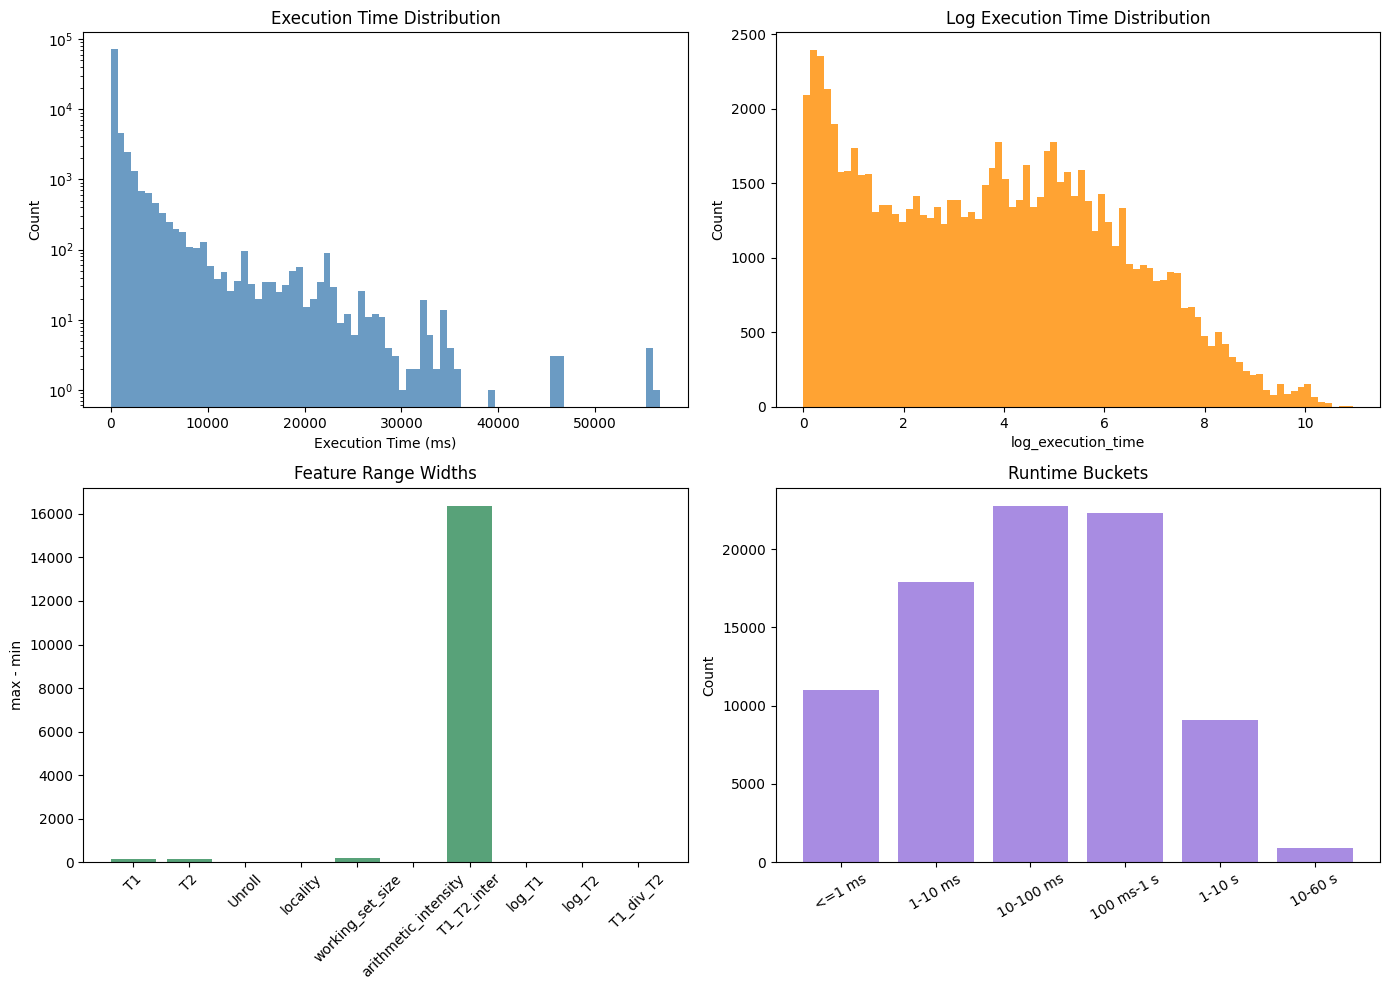

In [3]:
runtime_bins = [0, 1, 10, 100, 1000, 10000, 60000]
runtime_labels = ['<=1 ms', '1-10 ms', '10-100 ms', '100 ms-1 s', '1-10 s', '10-60 s']
runtime_bucket_counts = pd.cut(df['execution_time'], bins=runtime_bins, labels=runtime_labels, include_lowest=True).value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['execution_time'], bins=80, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Execution Time Distribution')
axes[0, 0].set_xlabel('Execution Time (ms)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_yscale('log')

axes[0, 1].hist(df['log_execution_time'], bins=80, color='darkorange', alpha=0.8)
axes[0, 1].set_title('Log Execution Time Distribution')
axes[0, 1].set_xlabel('log_execution_time')
axes[0, 1].set_ylabel('Count')

feature_ranges = df[FEATURE_COLS].agg(['min', 'max']).T
axes[1, 0].bar(feature_ranges.index, feature_ranges['max'] - feature_ranges['min'], color='seagreen', alpha=0.8)
axes[1, 0].set_title('Feature Range Widths')
axes[1, 0].set_ylabel('max - min')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(runtime_bucket_counts.index.astype(str), runtime_bucket_counts.values, color='mediumpurple', alpha=0.8)
axes[1, 1].set_title('Runtime Buckets')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [4]:
print('Planned fixes for the training notebooks:')
print('1. Standardize all 10 numeric schedule features using train-set statistics only.')
print('2. Remove the unroll-weighted loss, because Unroll is always positive in this dataset.')
print('3. Keep the log target, but report MAE, RMSE, median AE, and R^2 in milliseconds.')
print('4. Use a stronger code pooling strategy in Model 1 and keep cross-attention in Model 2.')
print('5. Keep the current row-level split for now, while noting that repeated Code_String values make grouped evaluation a future improvement.')

Planned fixes for the training notebooks:
1. Standardize all 10 numeric schedule features using train-set statistics only.
2. Remove the unroll-weighted loss, because Unroll is always positive in this dataset.
3. Keep the log target, but report MAE, RMSE, median AE, and R^2 in milliseconds.
4. Use a stronger code pooling strategy in Model 1 and keep cross-attention in Model 2.
5. Keep the current row-level split for now, while noting that repeated Code_String values make grouped evaluation a future improvement.
